## Preprocessing of the "domy" dataset

In [1]:
# to access sibling directories
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
from src.preprocessor_config import PreprocessorConfig
from src.preprocessor import Preprocessor
import pandas as pd
import scipy
import yaml
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

path_input  = '../data/raw/domy.csv'
path_output = '../data/processed/'
path_config = '../config/preprocessor.yaml'

use_log_transform = True

df = pd.read_csv(path_input)
with open(path_config, 'r') as f:
    cfg = PreprocessorConfig(**yaml.safe_load(f))

prepro = Preprocessor(df, cfg)
prepro.prepare_base_data()
prepro.df.to_csv('../data/processed/processed.csv')

MODEL_MAP = {
    "linear": lambda **params: LinearRegression(**params),
    "ridge": lambda **params: Ridge(**params),
    "lasso": lambda **params: Lasso(**params),
    "gridsearch": lambda **params: GridSearchCV(Lasso(), param_grid={'alpha': np.logspace(-3, -2, 50)}, **params),
    "randomizedsearch": lambda **params: RandomizedSearchCV(Lasso(), param_distributions={'alpha': scipy.stats.uniform(1e-4, 1.0)}, **params)
}

if cfg.model_type not in MODEL_MAP:
    raise ValueError(
        f"Model '{cfg.model_type}' not recognized. "
        f"Available options: {list(MODEL_MAP.keys())}"
    )

# metryki
mae_scores = []
rmse_scores = []
r2_scores = []

for X_train, X_test, y_train, y_test in prepro.get_folds():
    model = MODEL_MAP[cfg.model_type](**cfg.model_params)

    # trenuj
    if use_log_transform:
        y_train = np.log1p(y_train)
    model.fit(X_train, y_train)

    # przewiduj
    preds = model.predict(X_test)
    if use_log_transform:
        preds = np.expm1(preds)

    # oceń
    mae_scores.append(mean_absolute_error(y_test, preds))
    rmse_scores.append(root_mean_squared_error(y_test, preds))
    r2_scores.append(r2_score(y_test, preds))

if hasattr(model, 'alpha_'):
    print(f"Fold Alpha: {model.alpha_:.6f}")
if hasattr(model, 'best_params_'):
    print(f"Grid Best Alpha: {model.best_params_}")

print(f"Features: {X_train.shape[1]}")
print(f"Samples per X_train: {X_train.shape[0]}")

# results
print(f"Model type: {cfg.model_type} {type(model)}")
print(f"Model params: {cfg.model_params}")
print(f"Log Transform: {'Enabled' if use_log_transform else 'Disabled'}")
print("--------------")
print(f"Average MAE: ${np.mean(mae_scores):,.2f} (±{np.std(mae_scores):,.2f})")
print(f"Average RMSE: ${np.mean(rmse_scores):,.2f} (±{np.std(rmse_scores):,.2f})")
print(f"Average R²: {np.mean(r2_scores):.4f}")

Features: 145
Samples per X_train: 270
Model type: lasso <class 'sklearn.linear_model._coordinate_descent.Lasso'>
Model params: {'alpha': 0.0008}
Log Transform: Enabled
--------------
Average MAE: $11,939.99 (±1,052.84)
Average RMSE: $16,381.48 (±1,798.52)
Average R²: 0.8716


### Steps
0. Drop IDs (not something the model should learn from)
1. Handling missing data (1 column MasVnrType with nulls 60%)
2. Handling outliers
3. Encoding categorical values, handling weird numerals parsed into strings
4. Splitting the dataset into train and test sets
5. Scaling the dataset

### Historia wyników

start:
- Average MAE: $16,247.47 (±543.74)
- Average R²: 0.8586

po `use_log_transform`:
- Average MAE: $15,461.87 (±746.96)
- Average R²: 0.8729

po `gradations`:
- Average MAE: $15,207.32 (±990.92)
- Average R²: 0.8754

zmień model (ridge, alpha = 1.0):
- Average MAE: $15,179.71 (±969.21)
- Average R²: 0.8758

zmień model (lasso, alpha = 8e-4):
- Average MAE: $14,928.78 (±829.74)
- Average R²: 0.8798

duża poprawka: usuwaj outliery, nie clipuj

lasso:
- Average MAE: $11,294.12 (±848.95)
- Average RMSE: $14,894.65 (±1,180.58)
- Average R²: 0.8112

ridge:
- Average MAE: $11,601.99 (±1,414.87)
- Average RMSE: $15,280.20 (±1,940.44)
- Average R²: 0.8005

### Visualizing feature importance

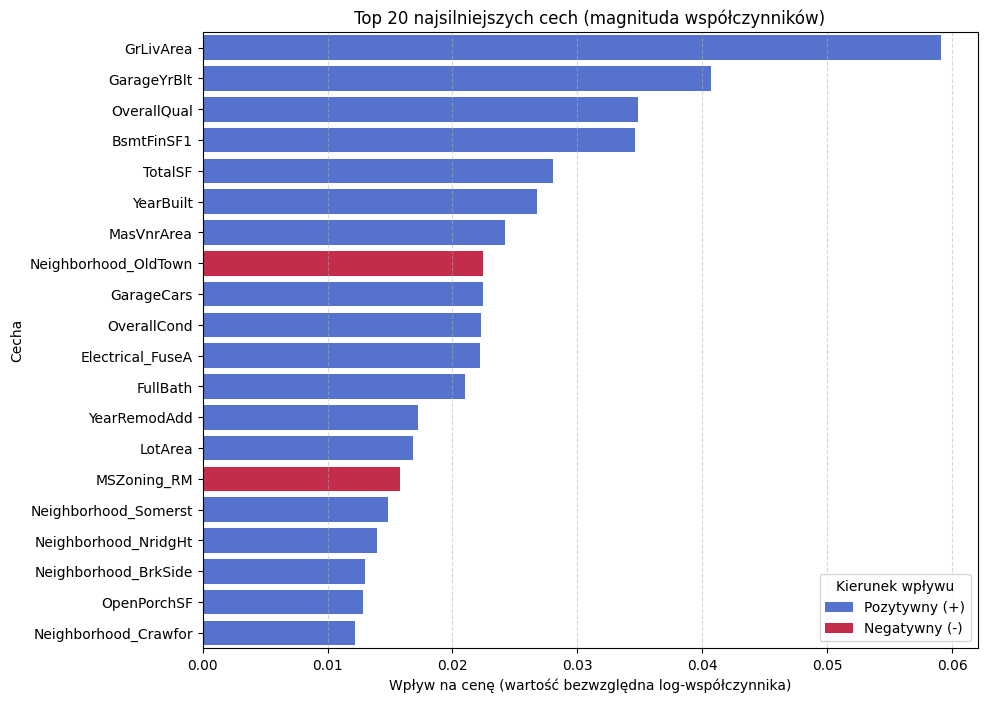

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_importance_unified(model, feature_names, top_n=20):
    final_model = getattr(model, 'best_estimator_', model)
    
    coefs = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': final_model.coef_
    })

    # Obliczamy wartość bezwzględną dla długości słupków
    coefs['Abs_Coef'] = coefs['Coefficient'].abs()
    
    # Kodujemy znak jako kategorię dla kolorów
    coefs['Wpływ'] = np.where(coefs['Coefficient'] > 0, 'Pozytywny (+)', 'Negatywny (-)')
    
    # Sortujemy po magnitudzie i bierzemy top N
    top_coefs = coefs.sort_values(by='Abs_Coef', ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=top_coefs, 
        x='Abs_Coef', 
        y='Feature', 
        hue='Wpływ',
        palette={'Pozytywny (+)': 'royalblue', 'Negatywny (-)': 'crimson'},
        dodge=False # Słupki będą jeden pod drugim, nie obok siebie
    )
    
    plt.title(f'Top {top_n} najsilniejszych cech (magnituda współczynników)')
    plt.xlabel('Wpływ na cenę (wartość bezwzględna log-współczynnika)')
    plt.ylabel('Cecha')
    plt.legend(title='Kierunek wpływu')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

plot_importance_unified(model, X_train.columns)

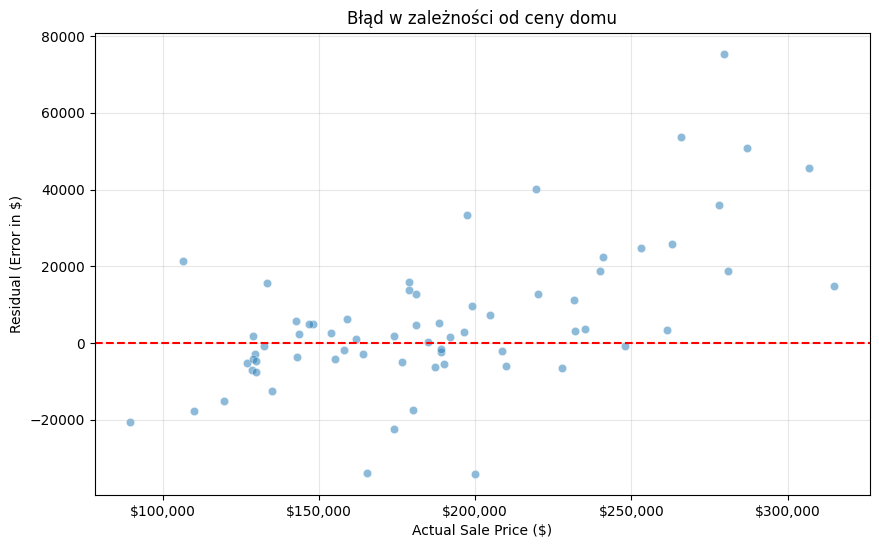

In [6]:
def plot_heteroscedasticity(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    
    plt.title('Błąd w zależności od ceny domu')
    plt.xlabel('Actual Sale Price ($)')
    plt.ylabel('Residual (Error in $)')
    
    # Formatowanie osi dla czytelności
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    plt.grid(True, alpha=0.3)
    plt.show()

# Wywołanie dla ostatniego foldu
plot_heteroscedasticity(y_test, preds)

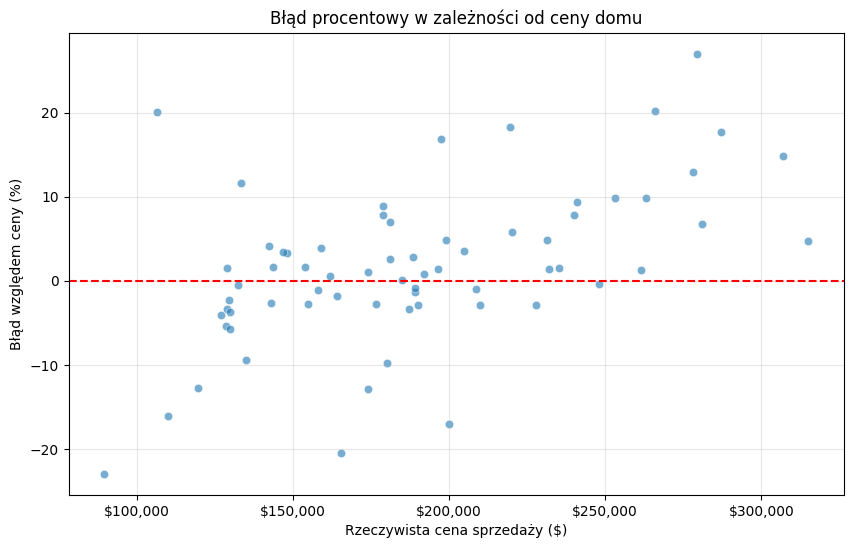

In [5]:
def plot_relative_error(y_true, y_pred):
    relative_error = ((y_true - y_pred) / y_true) * 100
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=relative_error, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    
    plt.title('Błąd procentowy w zależności od ceny domu')
    plt.xlabel('Rzeczywista cena sprzedaży ($)')
    plt.ylabel('Błąd względem ceny (%)')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    plt.grid(True, alpha=0.3)
    plt.show()
    
plot_relative_error(y_test, preds)